<a href="https://colab.research.google.com/github/NABI-SNU/book/blob/main/tutorials/Session_3_HiddenDynamics/student/Tutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/NABI-SNU/book/main/tutorials/Session_3_HiddenDynamics/student/Tutorial1.ipynb" target="_parent"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open in Kaggle"/></a>

# Hidden Dynamics
- This practice focuses on the practical use of Python Machine Learning libraries and visualization of synthetic dataset.

- Especially the *Latent State* and *Latent State Space* whether continuous or discontinuous

- Data genereated by **HMM**(HIdden Markov Model) will be analyzed by **MoG**(Mixture of Gaussian) and **FA**(Factor Analysis)

- All Data distributions are assumed to follow Gaussian distribution, for simplicity.

- Multi-Dimesnional Data Analysis are done using **PCA**(Principal Component Analysis).

각 코드에 대해서 코드가 어떤 의미인지 이해해보시고, colab 환경에서 실행해보시면 좋겠습니다:)

## 0. Dependencies

In [121]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from hmmlearn.hmm import GaussianHMM
from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score
from itertools import permutations

## 1. Synthetic Data Generation

In [122]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

In [123]:
def build_covariance(n, base_var, shared_var, rng):
    """Covariance matrix = shared_var * vvᵀ + base_var * I"""
    v = rng.standard_normal(n) #random vector
    v /= np.linalg.norm(v) #normalization(to unit vector)
    return shared_var * np.outer(v, v) + base_var * np.eye(n)


def generate_neural_data(n_neurons=20, n_timepoints=800,
                         transition_prob=0.5, rng=rng):
    mu0 = rng.uniform(0.2,  0.5,  size=n_neurons)
    mu1 = rng.uniform(-0.4, 0.2,  size=n_neurons)
    S0  = build_covariance(n_neurons, base_var=0.3, shared_var=0.8, rng=rng)
    S1  = build_covariance(n_neurons, base_var=0.8, shared_var=0.1, rng=rng)

    A  = np.array([[1 - transition_prob, transition_prob],
                   [transition_prob,     1 - transition_prob]])
    pi = np.array([0.5, 0.5])

    states    = np.empty(n_timepoints, dtype=int)
    states[0] = rng.choice(2, p=pi)
    for t in range(1, n_timepoints):
        states[t] = rng.choice(2, p=A[states[t - 1]])

    X = np.empty((n_timepoints, n_neurons))
    for t in range(n_timepoints):
        X[t] = rng.multivariate_normal(
            mu0 if states[t] == 0 else mu1,
            S0  if states[t] == 0 else S1,
        )

    return {"X": X, "states": states, "Sigma": [S0, S1], "mu": [mu0, mu1]}


In [124]:
data   = generate_neural_data(n_neurons=20, n_timepoints=800,transition_prob=0.02, rng=rng)
X      = data["X"]
states = data["states"]

In [125]:
print(f"    {X.shape}  | awake={np.sum(states==0)}, sleep={np.sum(states==1)}")

    (800, 20)  | awake=396, sleep=404


## 2.MoG and FA

-with no time-dependencies

In [126]:
def fit_static_fa(X, n_factors=2, max_iter=1000):
    ##FA 모델은 어떤 모델?, n_factors=2의미?
    fa = FactorAnalysis(n_components=n_factors, max_iter=max_iter,
                        random_state=RNG_SEED)
    fa.fit(X)
    return fa, fa.transform(X)

In [127]:
fa_model, Z_fa = fit_static_fa(X, n_factors=2)

In [128]:
def fit_mog(X, n_components=2, max_iter=300):
    ##MoG 모델은 어떤 모델??
    gmm = GaussianMixture(n_components=n_components,
                          covariance_type="full",
                          max_iter=max_iter,
                          n_init=5,
                          random_state=RNG_SEED)
    gmm.fit(X)
    labels = gmm.predict(X)
    return gmm, labels

In [129]:
def align_labels(true_states, predicted, n_components=2):
   #역할?
    best_acc, best_perm = -1, None
    for perm in permutations(range(n_components)):
        remapped = np.array([perm[s] for s in predicted])
        acc = accuracy_score(true_states, remapped)
        if acc > best_acc:
            best_acc, best_perm = acc, perm
    return np.array([best_perm[s] for s in predicted])

In [130]:
gmm, mog_labels_raw = fit_mog(X, n_components=2)
mog_labels = align_labels(states, mog_labels_raw)

## 3.Utilities

In [131]:
def participation_ratio(cov):
    #의미?
    eigs = np.linalg.eigvalsh(cov)
    eigs = eigs[eigs > 0]
    return (eigs.sum() ** 2) / (eigs ** 2).sum()

In [132]:
def print_summary(data, fa_model, Z_fa, gmm, mog_labels_aligned):
    states = data["states"]

    # FA
    fa_cd = np.linalg.norm(Z_fa[states == 0].mean(0) -
                            Z_fa[states == 1].mean(0))
    total_var = np.var(data["X"], axis=0).sum()
    fa_expl   = np.sum(fa_model.components_ ** 2) / total_var * 100

    # MoG
    mog_acc = accuracy_score(states, mog_labels_aligned)
    mog_ll  = gmm.score(data["X"]) * len(states)
    pr_hat  = [participation_ratio(gmm.covariances_[k]) for k in range(2)]
    pr_true = [participation_ratio(data["Sigma"][k]) for k in range(2)]

    print("\n" + "=" * 58)
    print("  TRUE COVARIANCE (generated)")
    print("=" * 58)
    for k, lbl in enumerate(["Awake", "Sleep"]):
        print(f"  Participation Ratio {lbl:6s} : {pr_true[k]:.2f}")

    print("\n" + "=" * 58)
    print("  STATIC FA  (unsupervised, continuous latent)")
    print("=" * 58)
    print(f"  Centroid dist. in latent space : {fa_cd:.4f}")
    print(f"  Variance explained (2 factors) : {fa_expl:.1f}%")
    print(f"  Noise variance (Psi) mean      : {fa_model.noise_variance_.mean():.4f}")

    print("\n" + "=" * 58)
    print("  MoG  (unsupervised, discrete latent)")
    print("=" * 58)
    print(f"  Cluster recovery accuracy      : {mog_acc:.4f}")
    print(f"  Total log-likelihood           : {mog_ll:.2f}")
    for k, lbl in enumerate(["Awake", "Sleep"]):
        print(f"  Participation Ratio {lbl:6s} : "
              f"learned={pr_hat[k]:.2f}  true={pr_true[k]:.2f}")
    print("=" * 58)

In [133]:
print_summary(data, fa_model, Z_fa, gmm, mog_labels)


  TRUE COVARIANCE (generated)
  Participation Ratio Awake  : 15.84
  Participation Ratio Sleep  : 19.99

  STATIC FA  (unsupervised, continuous latent)
  Centroid dist. in latent space : 1.4138
  Variance explained (2 factors) : 14.8%
  Noise variance (Psi) mean      : 0.5534

  MoG  (unsupervised, discrete latent)
  Cluster recovery accuracy      : 0.9800
  Total log-likelihood           : -17666.88
  Participation Ratio Awake  : learned=15.24  true=15.84
  Participation Ratio Sleep  : learned=18.99  true=19.99


## 4. Visualization

In [134]:
SC = {0: "#E8754A", 1: "#5B8DB8"}   # awake=orange, sleep=blue
def _style_ax(ax):
    ax.set_facecolor("#1A1A24")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for sp in ax.spines.values():
        sp.set_color("#444")


def confidence_ellipse(mean, cov, ax, n_std=2.0, color="white", lw=2.0):
    eigs, vecs = np.linalg.eigh(cov)
    order = eigs.argsort()[::-1]
    eigs, vecs = eigs[order], vecs[:, order]
    angle  = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h   = 2 * n_std * np.sqrt(eigs)
    ell    = Ellipse(xy=mean, width=w, height=h, angle=angle,
                     edgecolor=color, facecolor="none", lw=lw,
                     linestyle="--", zorder=5)
    ax.add_patch(ell)

In [ ]:
def plot_comparison(data, fa_model, Z_fa, gmm, mog_labels_aligned):
    X, states = data["X"], data["states"]
    T = len(states)
    t = np.arange(T)

    # PCA projection for MoG visualisation in observation space
    pca      = PCA(n_components=2, random_state=RNG_SEED)
    X_pca    = pca.fit_transform(X)
    W        = pca.components_                           # (2, n_neurons)
    mu_pca   = [pca.transform(gmm.means_[k][None, :])[0] for k in range(2)]
    S_pca    = [W @ gmm.covariances_[k] @ W.T for k in range(2)]

    fig = plt.figure(figsize=(17, 16), facecolor="#0F0F14")
    fig.suptitle(
        "Hidden Dynamics — Static FA (continuous latent)  vs.  MoG (discrete latent)",
        color="white", fontsize=13, fontweight="bold", y=0.988,
    )
    gs = gridspec.GridSpec(4, 2, figure=fig,
                           hspace=0.58, wspace=0.35,
                           left=0.07, right=0.96, top=0.96, bottom=0.04)


    # (A) Neural raster --------------------------------------------------------


    ax = fig.add_subplot(gs[0, :])
    ax.imshow(X.T, aspect="auto", cmap="plasma", interpolation="nearest")
    ax.set_title("(A) HMM-generated Neural Population Activity  [20 neurons × 800 t]",
                 fontsize=10)
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("Neuron")
    _style_ax(ax)


    # (B) Ground-truth state + MoG recovered assignment ----------------------


    ax = fig.add_subplot(gs[1, :])
    ax.step(t, states,              color=SC[0], lw=1.3,
            label="Ground truth", where="post")
    ax.step(t, mog_labels_aligned,  color=SC[1], lw=1.3, linestyle="--",
            label="MoG cluster", where="post", alpha=0.85)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Awake (0)", "Sleep (1)"], color="white")
    ax.set_title("(B) Ground-truth State vs. MoG Cluster Assignment",
                 fontsize=10)
    ax.set_xlabel("Time (samples)")
    ax.legend(facecolor="#1A1A24", labelcolor="white", fontsize=8)
    _style_ax(ax)


    # (C) FA latent & true state transitions---------------------------------


    ax = fig.add_subplot(gs[2, 0])
    transitions = np.where(np.diff(states) != 0)[0]
    for idx in transitions:
        seg = Z_fa[max(0, idx-5) : idx+6]
        ax.plot(seg[:, 0], seg[:, 1], color="yellow", lw=1.0, alpha=0.7)

    for s, lbl in zip([0, 1], ["Awake", "Sleep"]):
        m = states == s
        ax.scatter(Z_fa[m, 0], Z_fa[m, 1],
                c=SC[s], s=8, alpha=0.6, label=lbl,
                zorder=2, rasterized=True)             
    ax.set_title("(C) Static FA — Latent Space\n"
                 r"$z_t \in \mathbb{R}^2$, coloured by true state",
                 fontsize=9)
    ax.set_xlabel("Factor 1")
    ax.set_ylabel("Factor 2")
    ax.legend(facecolor="#1A1A24", labelcolor="white", fontsize=8)
    _style_ax(ax)


    # (D) MoG scatter in PCA space + confidence ellipses ---------------------


    ## (중요) Latent state space인가?


    ax = fig.add_subplot(gs[2, 1])
    for s, lbl in zip([0, 1], ["Awake", "Sleep"]):
        m = states == s
        ax.scatter(X_pca[m, 0], X_pca[m, 1],
                   c=SC[s], s=6, alpha=0.35, label=lbl, rasterized=True)
        confidence_ellipse(mu_pca[s], S_pca[s], ax,
                           n_std=2.0, color=SC[s], lw=2.0)
        ax.scatter(*mu_pca[s], marker="+", s=140, color=SC[s], zorder=6, lw=2)
    ax.set_title("(D) MoG — Learned Gaussians (PCA projection)\n"
                 "dashed = 2σ learned covariance,  + = learned mean",
                 fontsize=9)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend(facecolor="#1A1A24", labelcolor="white", fontsize=8)
    _style_ax(ax)


    # (E) FA factor time series -----------------------------------------------


    ax = fig.add_subplot(gs[3, 0])
    ax.plot(t, Z_fa[:, 0], color="#AEDCA0", lw=0.75, label="Factor 1")
    ax.plot(t, Z_fa[:, 1], color="#D4A5E8", lw=0.75, label="Factor 2", alpha=0.85)
    for i in range(T - 1):
        ax.axvspan(i, i + 1, alpha=0.07, color=SC[states[i]], lw=0)
    ax.set_title("(E) Static FA — Factor Trajectories\n"
                 "(background shaded by true state)",
                 fontsize=9)
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("Latent value")
    ax.legend(facecolor="#1A1A24", labelcolor="white", fontsize=8)
    _style_ax(ax)


    # (F) Covariance eigenspectra: true vs MoG learned ----------------------


    ax = fig.add_subplot(gs[3, 1])
    for k, lbl in enumerate(["Awake", "Sleep"]):
        eigs_true = np.sort(np.linalg.eigvalsh(data["Sigma"][k]))[::-1]
        eigs_mog  = np.sort(np.linalg.eigvalsh(gmm.covariances_[k]))[::-1]
        ax.plot(eigs_true, color=SC[k], lw=1.2, linestyle="--",
                label=f"{lbl} true", alpha=0.7)
        ax.plot(eigs_mog,  color=SC[k], lw=1.8, marker="o", ms=3,
                label=f"{lbl} MoG")
    ax.set_yscale("log")
    ax.set_title("(F) Covariance Eigenspectrum\n"
                 "solid = MoG learned,  dashed = true",
                 fontsize=9)
    ax.set_xlabel("Eigenvalue rank")
    ax.set_ylabel("Eigenvalue (log scale)")
    ax.legend(facecolor="#1A1A24", labelcolor="white", fontsize=7, ncol=2)
    _style_ax(ax)
    plt.tight_layout()
    plt.show(fig)

C:\Users\0923l\AppData\Local\Temp\ipykernel_14240\3638262788.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


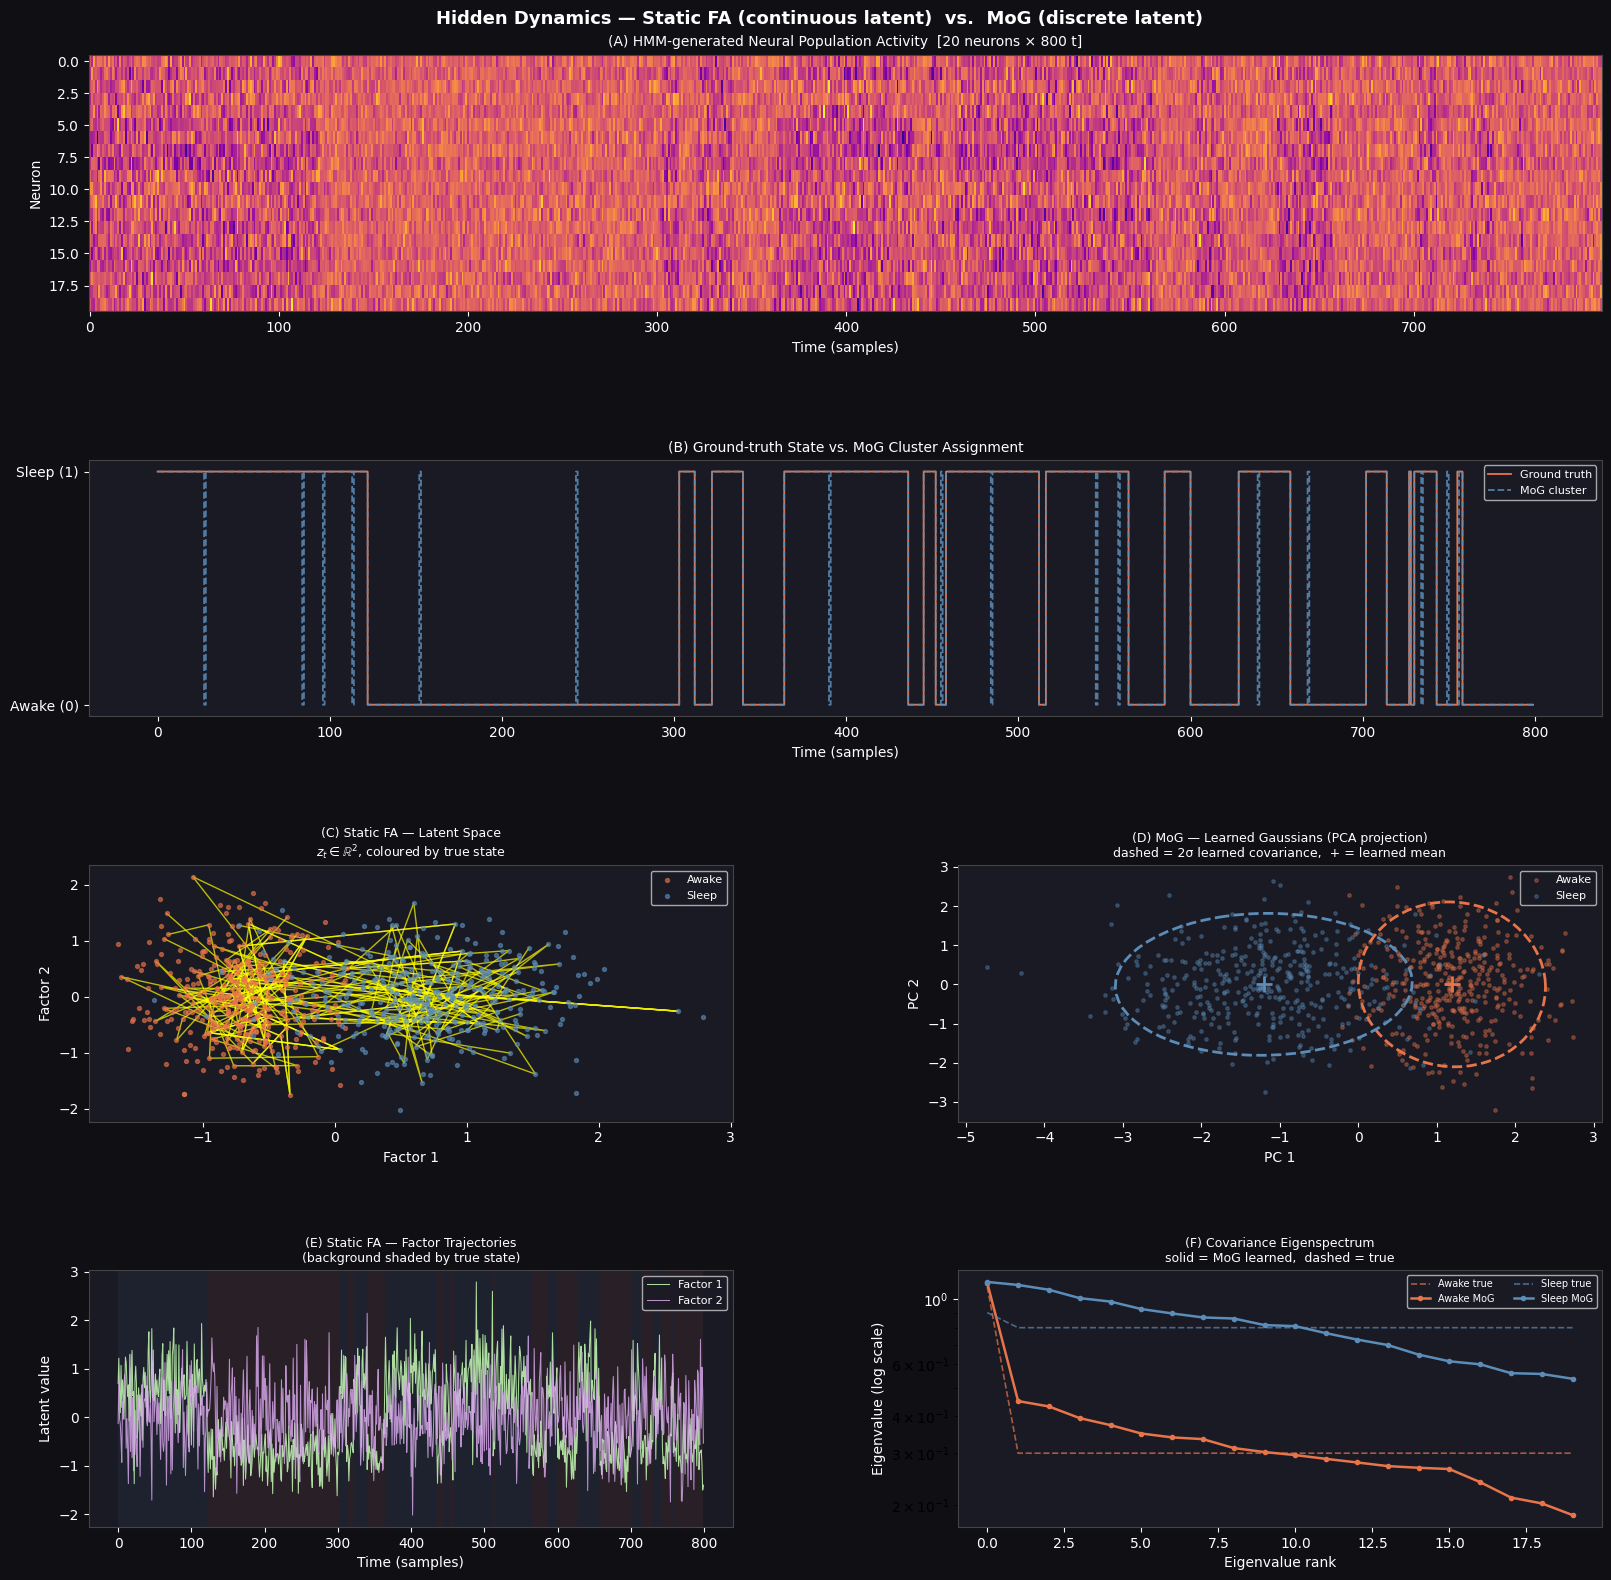

In [136]:
plot_comparison(data, fa_model, Z_fa, gmm, mog_labels)